In [1]:
import r5py as r5
import h3
import geopandas as gpd
from shapely.geometry import Polygon
from pyrosm import OSM
import numpy as np
from pyrosm.data import sources
from pyrosm import get_data
import matplotlib.pyplot as plt
import pandas as pd

### Getting hex grid

In [ ]:
osm_path = r"cities\brisbane\Brisbane.osm.pbf"

osm = OSM(osm_path)
boundaries = osm.get_boundaries()

In [3]:
gtfs_path = "cities\\brisbane\mdb-3048-202602280045.zip"
city_boundary = boundaries[boundaries['name'] == 'City of Brisbane']

# Automatically calculate the best local UTM CRS for this specific geometry
local_crs = city_boundary.estimate_utm_crs()
city_proj = city_boundary.to_crs(local_crs)

<Axes: >

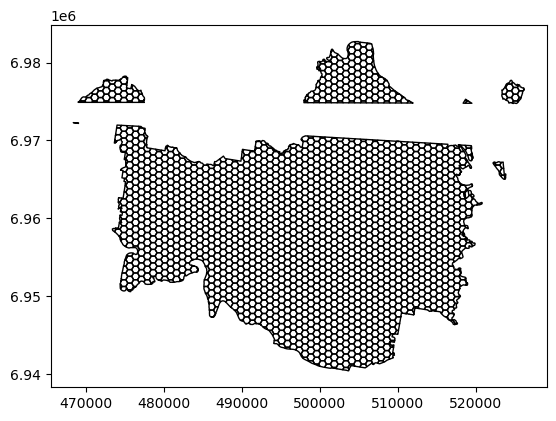

In [65]:
def create_hex_grid(gdf, radius_meters):
    xmin, ymin, xmax, ymax = gdf.total_bounds
    
    # constants for a flat-topped hexagon
    w = 2 * radius_meters
    h = np.sqrt(3) * radius_meters
    
    x_coords = np.arange(xmin - w, xmax + w, 1.5 * radius_meters)
    y_coords = np.arange(ymin - h, ymax + h, h)
    
    polys = []
    for i, x in enumerate(x_coords):
        for j, y in enumerate(y_coords):
            # Offset every odd column to lock the hexagons together
            y_curr = y + (h / 2) if i % 2 == 1 else y
            
            hex_points = [
                (x + radius_meters * np.cos(angle), y_curr + radius_meters * np.sin(angle))
                # 6 equidistant points around a circle
                for angle in np.linspace(0, 2 * np.pi, 7)[:-1] 
            ]
            polys.append(Polygon(hex_points))
            
    # Convert to GeoDataFrame
    grid = gpd.GeoDataFrame({'geometry': polys}, crs=gdf.crs)
    return gpd.clip(grid, gdf)

# Generate a grid where each hexagon has a center-to-corner radius of n meters
grid = create_hex_grid(city_proj, radius_meters=500)
grid.plot(edgecolor='black', facecolor='none')

### Preparing origin nodes and destination POIs

In [66]:
origins = grid.copy()       # Convert grid polygons to centroids
origins['id'] = range(len(grid))       # for grouping by id later

flat_crs_o = origins.estimate_utm_crs()
origins_flat = origins.to_crs(flat_crs_o)
origins_flat['geometry'] = origins_flat.centroid
origins = origins_flat.to_crs("EPSG:4326")

In [ ]:
destinations = osm.get_pois(custom_filter={'amenity': True})        #only look for amenities 
# By default pyrosm reads all elements having "amenity", "shop" or "tourism" tag
print(len(destinations['amenity'].unique()), destinations['amenity'].value_counts().head(20))

In [7]:
# .items() separates the amenity name and the count
for name, count in destinations['amenity'].value_counts().items():
    print(f"{name}: {count}")

parking: 8790
parking_space: 5940
bench: 4552
shelter: 3044
drinking_water: 1779
waste_basket: 1711
restaurant: 1298
fast_food: 1210
cafe: 1174
toilets: 1004
bicycle_parking: 893
post_box: 733
parking_entrance: 653
bbq: 641
telephone: 620
school: 600
place_of_worship: 566
fuel: 501
kindergarten: 453
recycling: 404
vending_machine: 305
social_facility: 268
pharmacy: 265
community_centre: 264
doctors: 249
clinic: 247
dentist: 245
pub: 231
bank: 168
childcare: 167
atm: 154
bar: 148
post_office: 132
veterinary: 126
ticket_validator: 106
trolley_bay: 103
charging_station: 90
library: 88
car_wash: 85
police: 84
fountain: 65
motorcycle_parking: 64
ferry_terminal: 62
ice_cream: 61
public_bookcase: 56
bus_station: 55
waste_disposal: 50
fire_station: 48
theatre: 46
taxi: 43
hospital: 43
car_rental: 42
compressed_air: 41
water_point: 40
cinema: 35
parcel_locker: 32
events_venue: 31
university: 30
bicycle_repair_station: 29
college: 27
traffic_park: 27
loading_dock: 26
studio: 25
weighbridge: 22
f

In [8]:
noise_categories = [
    'parking', 'bicycle_parking', 'bench', 'waste_basket', 'recycling', 'waste_disposal',
    'vending_machine', 'parking_entrance', 'post_box', 'hunting_stand', 'parking_space',
    'car_sharing', 'tourist_bus_parking', 'waste_transfer_station'
]

destinations_clean = destinations[~destinations['amenity'].isin(noise_categories)] # filter OUT

print(f"\nTotal POIs after removing noise: {len(destinations_clean)}")


Total POIs after removing noise: 17546


In [9]:
domain_mapping = {
    # Food & Drink
    'restaurant': 'food_and_drink', 'cafe': 'food_and_drink', 'bbq': 'food_and_drink',
    'fast_food': 'food_and_drink', 'bar': 'food_and_drink', 'pub': 'food_and_drink',
    
    # Healthcare
    'hospital': 'healthcare', 'clinic': 'healthcare', 
    'pharmacy': 'healthcare', 'doctors': 'healthcare', 'dentist': 'healthcare',
    
    # Education
    'school': 'education', 'kindergarten': 'education', 'library': 'education',
    'university': 'education', 'college': 'education', 'childcare': 'education',
    
    # Social / community 
    'community_centre': 'community', 'events_venue': 'community', 'theatre': 'community',
    'place_of_worship': 'community', 'social_facility': 'community',

    # entertainment
    'theatre': 'entertainment', 'cinema': 'entertainment',
    
    # Essential Services
    'bank': 'essential_services', 'post_office': 'essential_services', 'telephone': 'essential_services',
    'police': 'essential_services', 'fire_station': 'essential_services', 'atm': 'essential_services'
}

# Apply the mapping to a new column. 
# If a tag isn't in the dictionary, it just keeps its original OSM name.
destinations_clean['livability_domain'] = destinations_clean['amenity'].replace(domain_mapping)

print(destinations_clean['livability_domain'].value_counts().head(10))

livability_domain
food_and_drink        4702
shelter               3044
drinking_water        1779
education             1365
essential_services    1206
community             1129
healthcare            1049
toilets               1004
fuel                   501
veterinary             126
Name: count, dtype: int64


c:\Users\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [10]:
from datetime import timedelta

destinations_clean['id'] = range(len(destinations_clean))

# 1. Project to a flat, universal estimator
flat_crs_d = destinations_clean.estimate_utm_crs()

destinations_flat = destinations_clean.to_crs(flat_crs_d)
destinations_flat['geometry'] = destinations_flat.centroid

# 3. Project the newly created center points back to EPSG:4326 for r5py
destinations_clean = destinations_flat.to_crs("EPSG:4326")

c:\Users\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


### Transport Network & Time travel Matrix

In [11]:
tn = r5.TransportNetwork(osm_path, gtfs=gtfs_path)

In [12]:
food_destinations = destinations_clean[destinations_clean['livability_domain'] == 'food_and_drink'].copy()

In [13]:
travel_time_matrix = r5.TravelTimeMatrix(
    tn,
    origins=origins,
    destinations=food_destinations,
    transport_modes=[r5.TransportMode.TRANSIT, r5.TransportMode.WALK],
    max_time=timedelta(minutes=30) #CUTOFF
)

### Trying gravity based-measures

In [67]:
food_destinations["opp_weight"] = 1
ttm = travel_time_matrix.merge(
    food_destinations[["id", "opp_weight"]],
    left_on="to_id",
    right_on="id",
    how="left"
)

beta = 0.15  # tune this based on how steep you want decay to be

ttm["decay"] = np.exp(-beta * ttm["travel_time"])
ttm["gravity_component"] = ttm["opp_weight"] * ttm["decay"]

gravity_scores = (
    ttm.groupby("from_id", as_index=False)["gravity_component"]
    .sum()
    .rename(columns={"gravity_component": "food_gravity_score"})
)

origins = origins.merge(
    gravity_scores,
    left_on="id",
    right_on="from_id",
    how="left"
)

origins["food_gravity_score"] = origins["food_gravity_score"].fillna(0)

#### Population average

In [62]:
import rasterio
import rasterio.mask
from shapely.geometry import box

def assign_population_to_grid(pop_raster_path, grid, plot=True):
    """
    Assigns population from a GeoTIFF raster to a hex/polygon grid
    using areal disaggregation (proportional area-based allocation).

    Parameters
    ----------
    pop_raster_path : str
        Path to the population GeoTIFF file.
    grid : GeoDataFrame
        Polygon grid (hex or other) to assign population to.
        Can be in any CRS — will be handled internally.
    plot : bool
        If True, plots the resulting population map.

    Returns
    -------
    GeoDataFrame
        A copy of `grid` with a new `population` column.
    """
    grid_out = grid.copy().reset_index(drop=True)
    grid_out["id"] = grid_out.index.astype(str)

    with rasterio.open(pop_raster_path) as src:
        raster_crs = src.crs
        grid_raster_crs = grid_out.to_crs(raster_crs) # reproject grid to raster CRS for clipping
        
        geoms = list(grid_raster_crs.geometry.values) # clip raster to grid boundaries
        try:
            out_image, out_transform = rasterio.mask.mask(src, geoms, crop=True)
        except Exception as e:
            raise ValueError(f"Raster masking failed: {e}")

        nodata = src.nodata
        res_x = abs(out_transform.a)
        res_y = abs(out_transform.e)

    arr = out_image[0].astype(float) # apply mask 
    if nodata is not None:
        arr[arr == nodata] = np.nan

    rows, cols = np.where((~np.isnan(arr)) & (arr > 0))

    if len(rows) == 0: # data validity check
        print("Warning: No valid population values found in raster within grid extent.")
        grid_out["population"] = 0.0
        return grid_out

    xs, ys = rasterio.transform.xy(out_transform, rows, cols)
    pop_values = arr[rows, cols]

    # build rectangular cell polygons around each raster cell centre
    cell_polygons = [
        box(x - res_x / 2, y - res_y / 2, x + res_x / 2, y + res_y / 2)
        for x, y in zip(xs, ys)
    ]
    raster_cells = gpd.GeoDataFrame(
        {"cell_pop": pop_values},
        geometry=cell_polygons,
        crs=raster_crs
    )

    # --- 3) Reproject raster cells to grid CRS ---
    raster_cells = raster_cells.to_crs(grid_out.crs)
    raster_cells["cell_area"] = raster_cells.geometry.area

    # --- 4) Intersect raster cells with hex polygons ---
    intersection = gpd.overlay(
        raster_cells[["cell_pop", "cell_area", "geometry"]],
        grid_out[["id", "geometry"]],
        how="intersection"
    )

    if intersection.empty:
        print("Warning: No intersection between raster cells and grid.")
        grid_out["population"] = 0.0
        return grid_out

    # --- 5) Proportional allocation ---
    intersection["int_area"] = intersection.geometry.area
    intersection["pop_share"] = intersection["int_area"] / intersection["cell_area"]
    intersection["pop_allocated"] = intersection["cell_pop"] * intersection["pop_share"]

    hex_pop = (
        intersection.groupby("id")["pop_allocated"]
        .sum()
        .reset_index()
        .rename(columns={"pop_allocated": "population"})
    )

    # --- 6) Merge back onto original grid ---
    grid_out = grid_out.merge(hex_pop, on="id", how="left")
    grid_out["population"] = grid_out["population"].fillna(0.0)

    # --- 7) Validate totals ---
    raster_total = float(pop_values.sum())
    hex_total = float(grid_out["population"].sum())
    print(f"Raster total population:  {raster_total:,.0f}")
    print(f"Hex grid total population: {hex_total:,.0f}")
    print(f"Coverage: {hex_total / raster_total * 100:.1f}%")

    # --- 8) Optional plot ---
    if plot:
        fig, ax = plt.subplots(1, 1, figsize=(14, 12))
        grid_out.plot(
            column="population",
            cmap="YlOrRd",
            scheme="Quantiles",
            k=9,
            legend=True,
            linewidth=0.02,
            edgecolor="none",
            legend_kwds={
                "loc": "lower right",
                "title": "Population\n(9 quantiles)",
                "fmt": "{:.0f}"
            },
            ax=ax
        )
        ax.set_title("Population by Hexagon (areal disaggregation)", fontsize=18)
        ax.set_axis_off()
        plt.tight_layout()
        plt.show()

    return grid_out

Raster total population:  970,798
Hex grid total population: 958,467
Coverage: 98.7%


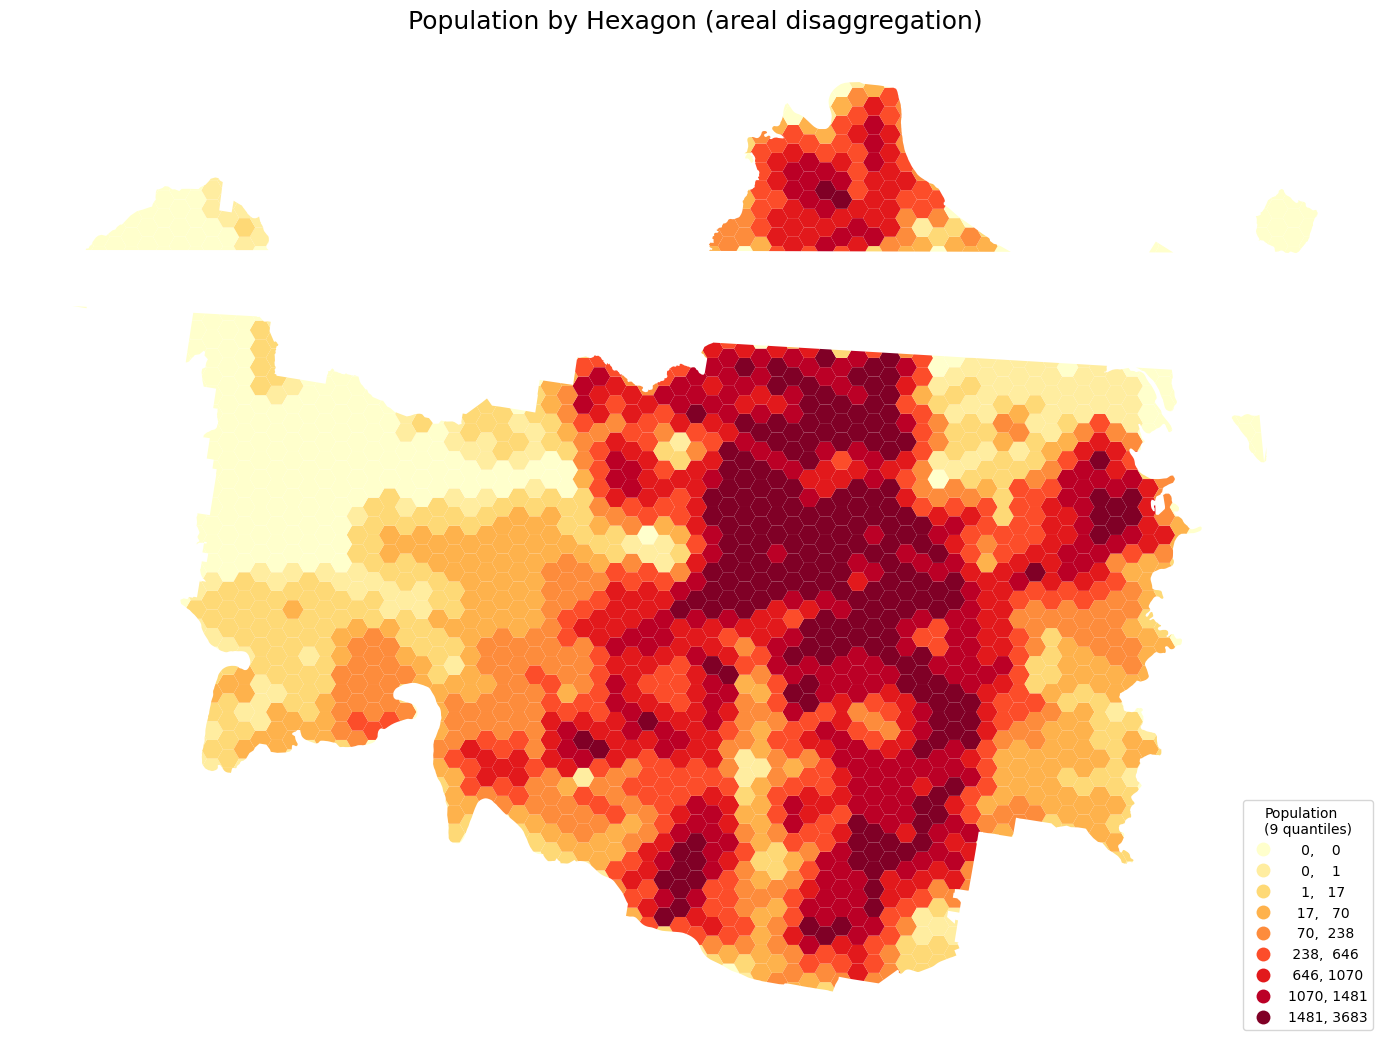

In [63]:
pop_raster = r"cities\brisbane\Australian_Population_Grid_2011.tif"
grid = create_hex_grid(city_proj, radius_meters=500)

grid_pop = assign_population_to_grid(pop_raster, grid, plot=True)

In [71]:
origins["id"] = origins["id"].astype(int)
grid_pop["id"] = grid_pop["id"].astype(int)
origins = origins.merge(
    grid_pop[["id", "population"]],
    on="id",
    how="left"
)
origins["population"] = origins["population"].fillna(0)

# city-wide population-weighted score
total_pop = origins["population"].sum()
city_food_score = (
    (origins["food_gravity_score"] * origins["population"]).sum()
    / total_pop
)

print(f"--- Brisbane: Food Accessibility ---")
print(f"City-wide score (pop-weighted): {city_food_score:.4f}")
print(f"Median hex score:               {origins['food_gravity_score'].median():.4f}")
print(f"10th percentile:                {origins['food_gravity_score'].quantile(0.10):.4f}")
print(f"90th percentile:                {origins['food_gravity_score'].quantile(0.90):.4f}")
print(f"Population covered:             {total_pop:,.0f}")

--- Brisbane: Food Accessibility ---
City-wide score (pop-weighted): 6.1529
Median hex score:               0.5094
10th percentile:                0.0000
90th percentile:                4.2239
Population covered:             958,467


In [32]:
grid = grid.copy()
grid["id"] = range(len(grid))

grid_scored = grid.merge(
    origins[["id", "food_gravity_score"]],
    on="id",
    how="left"
)

grid_scored["food_gravity_score"] = grid_scored["food_gravity_score"].fillna(0)

c:\Users\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting k to 14.
  self.bins = quantile(y, k=k)


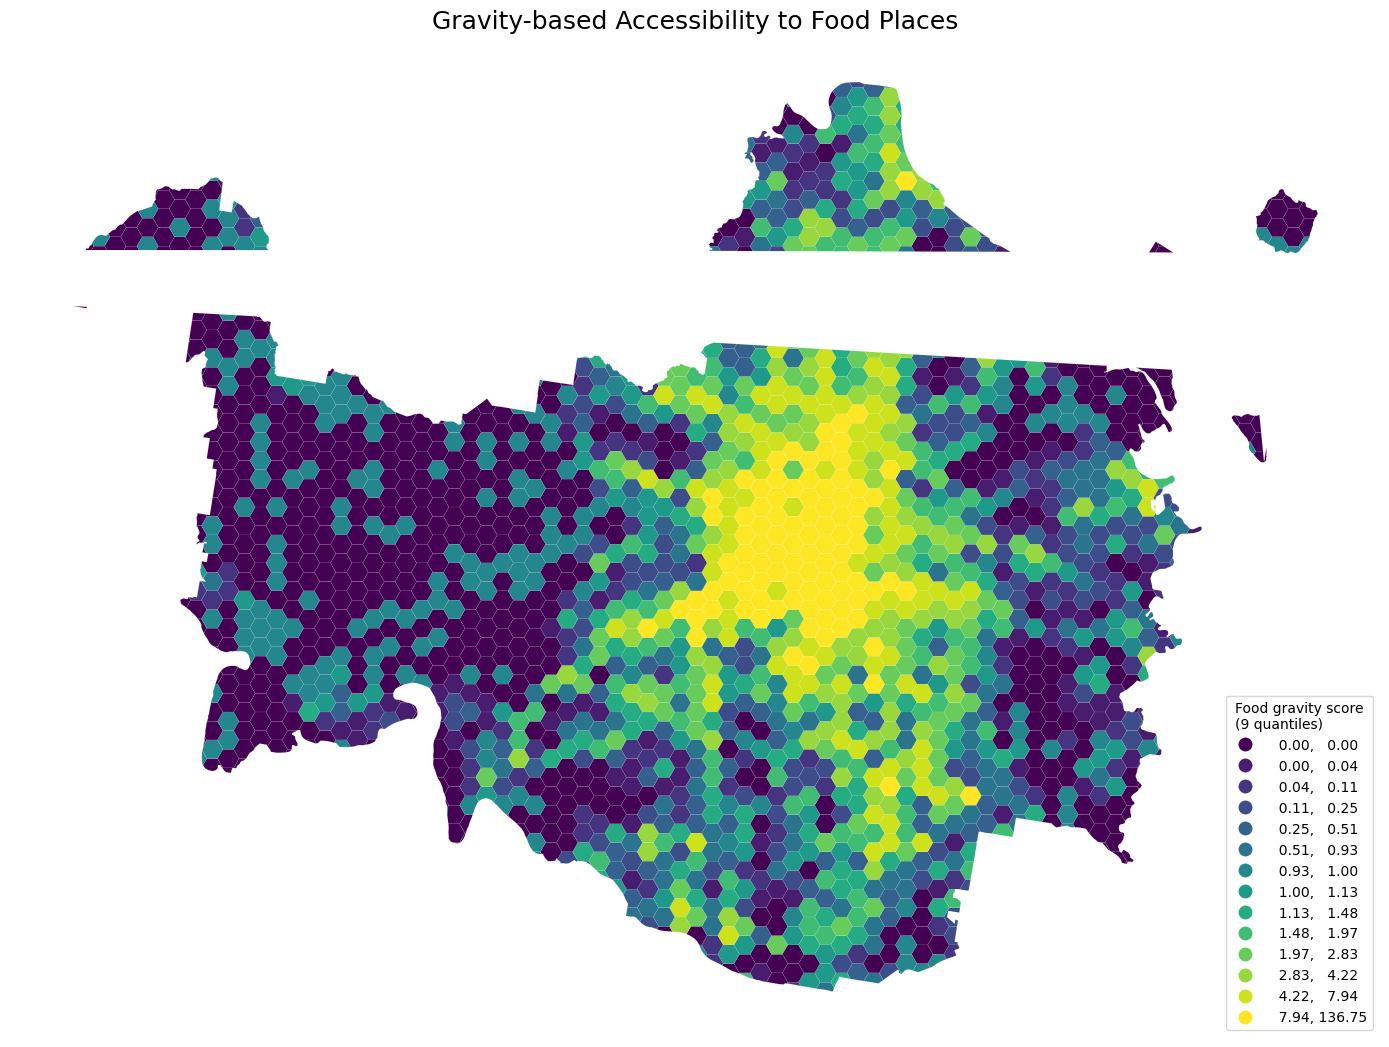

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

grid_scored.plot(
    column="food_gravity_score",
    cmap="viridis",
    scheme="quantiles",
    k=20,
    legend=True,
    linewidth=0.05,
    edgecolor="white",
    legend_kwds={
        "loc": "lower right",
        "title": "Food gravity score\n(9 quantiles)",
        "fmt": "{:.2f}"
    },
    ax=ax
)

ax.set_title("Gravity-based Accessibility to Food Places", fontsize=18)
ax.set_axis_off()
plt.tight_layout()
plt.show()